# Resort Churn — Neural Network with Optuna Hyperparameter Tuning

This is a derivative of `resort_nn.ipynb`. The data loading and preprocessing are identical;
the difference is that instead of picking the network's hyperparameters by hand we let
[**Optuna**](https://optuna.org/) search for them.

**What Optuna does in one paragraph:** you write an `objective(trial)` function that builds and
trains a model using values pulled from `trial.suggest_*` (e.g. `trial.suggest_float('lr', ...)`).
You return a number to minimize (or maximize). Optuna runs the objective many times, learning
from each trial's outcome to bias future trials toward promising regions of the search space
using a Tree-structured Parzen Estimator (TPE) by default. It also **prunes** bad trials early
so we don't waste compute training models that are obviously going to be worse than what we've
already seen.

**Search space (this notebook):**
- Hidden layer sizes (two layers)
- Dropout rate
- Learning rate (log-uniform)
- Weight decay (log-uniform)
- Batch size
- Optimizer (Adam vs AdamW)

**Objective:** maximize validation ROC AUC. AUC is a better target than accuracy for class-
imbalanced problems because it's threshold-independent.

## 1. Imports + setup

Same stack as before plus `optuna`. Uncomment the install line if needed.

In [1]:
# !pip install pandas numpy scikit-learn torch matplotlib optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import optuna
# Optuna logs every trial at INFO by default; bump to WARNING so the notebook output
# stays readable. Comment this out if you want to see per-trial chatter.
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Load + preprocess data

We load the **cleaned** train file. The cleaned file has already had `BookingDate` removed, the
`Room` string exploded into `RoomFloor` / `RoomNumber` / `RoomSide` / `SharedRoom`, and missing
`PromoCode` filled with `"NoPromoCode"`, so all we need to do here is drop `GuestID` and separate
the target.

There is no global train/val split — the previous version held out 15% for Optuna to score
against, which was noisy (one split, ~1k rows). Each trial now does **K-fold cross-validation
internally**, so the held-out signal is averaged over K folds. The preprocessor is fit inside
each fold (on that fold's training portion only) to avoid leakage.

The actual test data still lives in a separate file (`churn_test_cleaned.csv`) and is used at the
very end of the notebook to produce `submission.csv`.

In [2]:
TRAIN_PATH = "/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/Nick/churn_train_cleaned.csv"
TEST_PATH  = "/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/Nick/churn_test_cleaned.csv"

train = pd.read_csv(TRAIN_PATH)

TARGET = "Churned"
y = train[TARGET].astype(np.float32).values
# Drop GuestID (just an identifier) and the target itself from the feature matrix.
X = train.drop(columns=[TARGET, "GuestID"]).reset_index(drop=True)

# Auto-detect numeric vs categorical columns by dtype.
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols     = X.select_dtypes(include=[np.number]).columns.tolist()

# No global train/val split anymore — Optuna scores each trial via K-fold CV inside the
# objective, so the held-out signal comes from the CV folds themselves. The preprocessor is
# fit *inside each fold* to avoid leakage (imputation medians and one-hot vocabs depend on
# the training data of that fold). We define a builder so the objective and the final
# retrain can reuse the same recipe.
def build_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_cols),
    ])

print(f"Full training data: {X.shape}")
print(f"Numeric cols    ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical cols ({len(categorical_cols)}): {categorical_cols}")
print(f"Positive class rate: {y.mean():.3f}")


Full training data: (6954, 59)
Numeric cols    (14): ['AllInclusive', 'VIP', 'RoomService', 'Dining', 'Retail', 'Spa', 'Entertainment', 'LoyaltyPoints', 'SurveyScore', 'DaysSinceEmail', 'SharedRoom', 'RoomNumber', 'BookingMonth', 'BookingYear']
Categorical cols (0): []
Positive class rate: 0.504


## 3. Parametric model builder

We rewrite `ChurnMLP` to take hyperparameters as arguments. The Optuna objective will call this
with whatever values the sampler picks.

In [3]:
class ChurnMLP(nn.Module):
    """MLP with a configurable number of hidden layers.

    `hidden_sizes` is a list of layer widths, e.g. [128, 64] for two hidden layers or
    [128, 64, 32] for three. We expanded the search space to let Optuna pick 2 or 3 layers.
    """
    def __init__(self, in_features, hidden_sizes, dropout):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4. The Optuna objective

Each trial:
1. Samples hyperparameters via `trial.suggest_*` (the search space is now wider — see below).
2. Builds **K models in parallel** — one per CV fold — each with its own preprocessor fit on
   that fold's training portion only.
3. Trains all K models epoch-by-epoch in lockstep. After every epoch we compute the mean val
   AUC across all K held-out folds.
4. **Reports** that mean AUC to Optuna each epoch and checks `trial.should_prune()`. With the
   `HyperbandPruner` (configured in the next cell), trials that look weak after their allocated
   budget get killed and the saved compute goes to more promising candidates.
5. Returns the **best** mean val AUC seen across epochs — same lightweight-early-stopping idea
   as before, just averaged across folds for a less-noisy signal.

**Why K-fold per trial?** A single 15% val split is ~1k rows here, which makes AUC swing by
~0.005–0.01 just from sampling noise. That noise is enough to make Optuna chase phantom
"improvements." 3-fold CV roughly cuts that noise by `sqrt(3)` at 3× the per-trial cost — a
worthwhile trade as long as we don't blow the total budget.

**Expanded search space:**
- `n_hidden_layers` ∈ {2, 3} *(new)*
- `hidden1`, `hidden2`, `hidden3` — wider range (up to 384 vs 256 before), `hidden3` only used
  when `n_hidden_layers == 3`
- `dropout` ∈ [0.0, 0.6] *(was 0.5)*
- `lr` ∈ [5e-5, 5e-2] log-uniform *(wider than 1e-4 to 1e-2)*
- `weight_decay` ∈ [1e-8, 1e-2] log-uniform *(wider)*
- `batch_size` ∈ {64, 128, 256, 512}
- `optimizer` ∈ {Adam, AdamW}

The note about freezing unimportant knobs applies *after* you've inspected the parameter
importance plot in section 6 — if you find e.g. `optimizer` barely matters, replace its
`suggest_categorical` with a hardcoded value and put the saved budget into the knobs that do
matter.

In [4]:
from sklearn.model_selection import StratifiedKFold

TRIAL_EPOCHS = 20  # shorter than the final-model training; tuning is exploratory
K_FOLDS      = 3   # CV folds per trial — total cost scales linearly with this

# Reuse the same fold assignments for every trial so we're not introducing extra noise from
# resampling. Stratified to preserve the churn rate in each fold.
_skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
CV_FOLDS = list(_skf.split(X, y))

def objective(trial: optuna.Trial) -> float:
    # ---- 1. Sample hyperparameters ----
    n_layers = trial.suggest_int("n_hidden_layers", 2, 3)
    hidden1  = trial.suggest_int("hidden1", 32, 384, step=16)
    hidden2  = trial.suggest_int("hidden2", 16, hidden1, step=16)
    if n_layers == 3:
        hidden3 = trial.suggest_int("hidden3", 16, hidden2, step=16)
        hidden_sizes = [hidden1, hidden2, hidden3]
    else:
        hidden_sizes = [hidden1, hidden2]

    dropout      = trial.suggest_float("dropout",      0.0, 0.6)
    lr           = trial.suggest_float("lr",           5e-5, 5e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [64, 128, 256, 512])
    optim_name   = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    optim_cls    = {"Adam": torch.optim.Adam, "AdamW": torch.optim.AdamW}[optim_name]

    # ---- 2. Build K parallel fold-level training contexts ----
    # We fit the preprocessor inside each fold (on the fold's training rows only) so val rows
    # never influence the imputer medians, scaler stats, or one-hot vocabularies.
    criterion = nn.BCEWithLogitsLoss()
    fold_ctx = []  # one dict per fold: model, optimizer, train_loader, X_val_t, y_val_arr
    for tr_idx, va_idx in CV_FOLDS:
        preproc = build_preprocessor()
        X_tr = preproc.fit_transform(X.iloc[tr_idx])
        X_va = preproc.transform(X.iloc[va_idx])
        n_feat = X_tr.shape[1]

        X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
        y_tr_t = torch.tensor(y[tr_idx], dtype=torch.float32).unsqueeze(1)
        X_va_t = torch.tensor(X_va, dtype=torch.float32)

        model = ChurnMLP(n_feat, hidden_sizes, dropout).to(device)
        optimizer = optim_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
        train_loader = DataLoader(
            TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True
        )

        fold_ctx.append({
            "model": model,
            "optimizer": optimizer,
            "train_loader": train_loader,
            "X_val_t": X_va_t,
            "y_val": y[va_idx],
        })

    # ---- 3. Train all folds in lockstep, epoch by epoch ----
    # Reporting at the epoch level (rather than per-fold) gives HyperbandPruner the granular
    # learning-curve signal it expects.
    best_mean_auc = 0.0
    for epoch in range(TRIAL_EPOCHS):
        fold_aucs = []
        for ctx in fold_ctx:
            ctx["model"].train()
            for xb, yb in ctx["train_loader"]:
                xb, yb = xb.to(device), yb.to(device)
                ctx["optimizer"].zero_grad()
                loss = criterion(ctx["model"](xb), yb)
                loss.backward()
                ctx["optimizer"].step()

            ctx["model"].eval()
            with torch.no_grad():
                logits = ctx["model"](ctx["X_val_t"].to(device))
                probs  = torch.sigmoid(logits).cpu().numpy().ravel()
            fold_aucs.append(roc_auc_score(ctx["y_val"], probs))

        mean_auc = float(np.mean(fold_aucs))
        best_mean_auc = max(best_mean_auc, mean_auc)

        # ---- 4. Report + maybe prune ----
        trial.report(mean_auc, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_mean_auc

## 5. Run the Optuna study

- **Sampler**: TPE (Tree-structured Parzen Estimator), Optuna's default. It models the
  distribution of good vs bad trials and samples from where good ones tend to live.
- **Pruner**: `HyperbandPruner`. Hyperband runs multiple "brackets" of trials at different
  budget levels — most trials get only a small epoch budget, and only the survivors get
  promoted to longer runs. This is a strict upgrade over `MedianPruner` once you have more
  than a few dozen trials, because it doesn't waste a fixed warm-up budget on obviously-bad
  trials. We set `min_resource=3` (kill nothing in the first 3 epochs — the AUC curve is too
  noisy that early to be informative) and `max_resource=TRIAL_EPOCHS` so the full ladder maps
  onto our epoch count. `reduction_factor=3` is Hyperband's standard `η` value: after each
  rung, keep the top 1/3 of trials.
- **Direction**: `"maximize"` because higher AUC is better.

`N_TRIALS = 120` — the search space is wider than before (added `n_hidden_layers`, broadened
`lr`/`dropout`/`weight_decay`), and per-trial cost roughly tripled because of the 3-fold CV.
HyperbandPruner kills weak trials cheaply so the wall-clock impact is smaller than the raw
3×120 vs 1×60 ratio implies. Bump `N_TRIALS` higher if you have the compute.

In [5]:
N_TRIALS = 120

sampler = optuna.samplers.TPESampler(seed=SEED)
pruner  = optuna.pruners.HyperbandPruner(
    min_resource=3,
    max_resource=TRIAL_EPOCHS,
    reduction_factor=3,
)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
# show_progress_bar=True prints a tqdm bar; set it False if you're running headless / in CI.
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest trial:")
print("  mean CV AUC:", study.best_value)
print("  params :")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

# How many trials Optuna pruned vs ran to completion. HyperbandPruner is aggressive — expect
# most trials to be pruned, with only the strong ones running the full epoch budget. If almost
# nothing is pruned, the bracket structure isn't biting; if everything is pruned the budget is
# probably too small for any trial to reach max_resource.
n_pruned    = sum(t.state == optuna.trial.TrialState.PRUNED   for t in study.trials)
n_completed = sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)
print(f"\nTrials: {n_completed} completed, {n_pruned} pruned, {len(study.trials)} total")

  0%|          | 0/120 [00:00<?, ?it/s]


Best trial:
  mean CV AUC: 0.8106567472034216
  params :
    n_hidden_layers: 3
    hidden1: 80
    hidden2: 32
    hidden3: 16
    dropout: 0.5876389893064458
    lr: 0.005116378382673269
    weight_decay: 1.6730284893284915e-05
    batch_size: 64
    optimizer: Adam

Trials: 27 completed, 93 pruned, 120 total


## 6. Inspect the study

A few diagnostic plots:
- **Optimization history** — best score over trials. Should trend up (we're maximizing).
- **Parameter importances** — Optuna fits a fANOVA model to estimate which hyperparameters
  mattered most for the objective.

**How to use the importance plot for a follow-up run.** The expanded search space above is
deliberately broad — that's the right starting point, but wider spaces need more trials to
search well. After you've run a study, look at the importance plot and **freeze any knob whose
importance is near zero** by replacing its `trial.suggest_*` call with a hardcoded value (the
best-trial value is a safe default). That redirects budget to the dimensions that actually
move the score.

In [6]:
# Trials as a DataFrame for ad-hoc analysis.
trials_df = study.trials_dataframe(attrs=("number", "value", "state", "params"))
trials_df.head(10)

,number,value,state,params_batch_size,params_dropout,params_hidden1,params_hidden2,params_hidden3,params_lr,params_n_hidden_layers,params_optimizer,params_weight_decay
0,0,0.806532,COMPLETE,128,0.359195,368,272,NaN,0.000147,2,AdamW,8.629132e-08
1,1,0.809436,COMPLETE,128,0.182545,96,32,16.0,0.001876,3,AdamW,3.905441e-06
2,2,0.807985,COMPLETE,256,0.027870,96,64,48.0,0.003324,3,Adam,1.054738e-07
3,3,0.806138,PRUNED,64,0.020633,192,32,16.0,0.026726,3,AdamW,3.570096e-07
4,4,0.802141,PRUNED,256,0.553125,368,336,208.0,0.000092,3,Adam,1.499330e-07
5,5,0.733084,PRUNED,512,0.481318,224,32,NaN,0.000084,2,AdamW,8.342988e-03
6,6,0.795975,PRUNED,512,0.517862,48,32,16.0,0.003706,3,AdamW,9.669147e-07
7,7,0.808680,COMPLETE,128,0.456471,64,48,NaN,0.002414,2,Adam,4.224770e-04
8,8,0.804697,PRUNED,256,0.149575,144,80,80.0,0.000851,3,Adam,3.414341e-04
9,9,0.809221,COMPLETE,64,0.535535,352,288,64.0,0.002075,3,AdamW,6.992636e-04


/var/folders/gs/161p8px5645bt7rwtlw7t_w40000gn/T/ipykernel_62955/3848698782.py:9: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


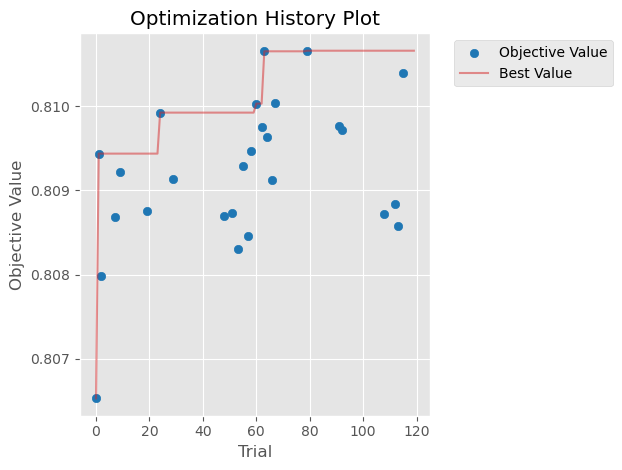

/var/folders/gs/161p8px5645bt7rwtlw7t_w40000gn/T/ipykernel_62955/3848698782.py:12: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


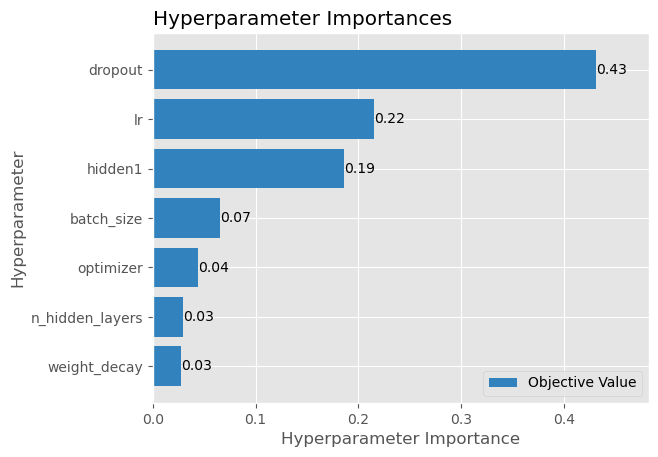

In [7]:
# Optuna ships matplotlib-based plots in optuna.visualization.matplotlib. If the matplotlib
# submodule isn't available in your install, the equivalent plotly versions live in
# optuna.visualization (no `.matplotlib` suffix).
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)

plot_optimization_history(study)
plt.show()

plot_param_importances(study)
plt.show()

## 7. Retrain the best configuration on the full training set

Tuning is done. Standard practice now:
1. Take the best hyperparameters Optuna found.
2. Fit the preprocessor on the **full** training data (X, y) and transform.
3. Train a single model on the full data for a few more epochs than tuning used (trials were
   intentionally short).

Because we used K-fold CV during tuning, the best-trial's `mean CV AUC` is already a
held-out-style estimate — we're not "spending" a val set we'd otherwise hold back.

In [8]:
best = study.best_params
FINAL_EPOCHS = 40

# Reconstruct hidden_sizes from the best trial's params.
if best["n_hidden_layers"] == 3:
    best_hidden_sizes = [best["hidden1"], best["hidden2"], best["hidden3"]]
else:
    best_hidden_sizes = [best["hidden1"], best["hidden2"]]

# Fit a fresh preprocessor on the full training data.
final_preprocessor = build_preprocessor()
X_full = final_preprocessor.fit_transform(X)
n_features_final = X_full.shape[1]

X_full_t = torch.tensor(X_full, dtype=torch.float32)
y_full_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

full_loader = DataLoader(
    TensorDataset(X_full_t, y_full_t), batch_size=best["batch_size"], shuffle=True
)

final_model = ChurnMLP(n_features_final, best_hidden_sizes, best["dropout"]).to(device)

optim_cls = {"Adam": torch.optim.Adam, "AdamW": torch.optim.AdamW}[best["optimizer"]]
optimizer = optim_cls(
    final_model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"]
)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    running = 0.0
    for xb, yb in full_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | train_loss={running / len(X_full_t):.4f}")


Epoch 01 | train_loss=0.6352
Epoch 05 | train_loss=0.5591
Epoch 10 | train_loss=0.5430
Epoch 15 | train_loss=0.5455
Epoch 20 | train_loss=0.5474
Epoch 25 | train_loss=0.5406
Epoch 30 | train_loss=0.5491
Epoch 35 | train_loss=0.5434
Epoch 40 | train_loss=0.5444


## 8. Predict on the external test file and write `submission.csv`

The cleaned test file has the same columns as the cleaned train file **except** for the `Churned`
target (that's what we're predicting). We:
1. Load it.
2. Strip `GuestID` for the feature matrix, but keep it aside for the submission.
3. Transform with the **same fitted preprocessor** used for the final model (`final_preprocessor`)
   so the column order and one-hot encoding match exactly.
4. Run the model, threshold at 0.5, attach the predictions to the `GuestID` column, and write
   `submission.csv`.


In [9]:
test = pd.read_csv(TEST_PATH)

# Keep GuestID for the submission file; drop it from the feature matrix.
test_features = test.drop(columns=["GuestID"])

# Transform using the preprocessor we just fit on full train+val.
# handle_unknown="ignore" on the one-hot encoder means any unseen category in the test file
# becomes an all-zero row for that feature group rather than crashing.
X_test_final = final_preprocessor.transform(test_features)
X_test_final_t = torch.tensor(X_test_final, dtype=torch.float32)

final_model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(final_model(X_test_final_t.to(device))).cpu().numpy().ravel()
test_preds = (test_probs >= 0.5).astype(int)

# Build submission: GuestIDs from the test file + predicted Churned column.
submission = test[["GuestID"]].copy()
submission["Churned"] = test_preds
submission.to_csv("submission.csv", index=False)

print(f"Wrote submission.csv with {len(submission)} rows.")
print(f"Predicted churn rate: {test_preds.mean():.3f}")
print(submission.head())


Wrote submission.csv with 1739 rows.
Predicted churn rate: 0.397
   GuestID  Churned
0   154038        1
1   620160        1
2   655103        0
3   126993        0
4   635228        0


## Notes / further ideas

- **Persist the study.** Pass `storage="sqlite:///resort_optuna.db"` and `study_name=...` to
  `create_study` (with `load_if_exists=True`) so you can resume or share studies across runs.
- **Parallelism.** Optuna can run trials in parallel — either with multiple processes pointing
  at the same SQLite/RDB storage, or with `n_jobs > 1` (be careful: PyTorch threading + Python's
  GIL means `n_jobs` only helps if the bottleneck releases the GIL).
- **Repeated CV.** Beyond the K-fold-per-trial we already do, a fixed RNG seed for the fold
  split means every trial sees the *same* folds. Re-seeding per trial (or running repeated CV)
  would give an even less noisy estimate at additional cost.
- **Threshold tuning.** We threshold at 0.5 when producing the submission. If the metric is
  e.g. F1 or expected business value, the optimal threshold is usually not 0.5 — sweep it on
  out-of-fold predictions.